In [1]:
from SFstarred.DataStarred import DataStarred
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm, LogNorm, Normalize, TwoSlopeNorm
import numpy as np

/Users/felavila/miniconda3/envs/SFstarred/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

## Overview

In this notebook, I summarize the main features used to read HST images, select lens systems, cut out stars, and save the resulting data products.

In [21]:
path_data = "../../../HST/hst_15320_13_wfc3_uvis_f475x_idgc13/hst_15320_13_wfc3_uvis_f475x_idgc13_drc.fits"
# path_weight = "/data/favila/data_2/HST_IMAGES_0214_2105/WG0214-2105_F160W_drz_wht.fits"
# Data setup for starred
#remove_star: 5 (light contamination from other source), 8 (it is one of the QSO images); 9 (large residuals) 
data = DataStarred(path_data)

Background diagnostics
----------------------
mean_resid        = -0.03303 e-
median_resid      = -0.006778 e-
std_resid         = 7.095 e-
median sky RMS    = 6.903 e-
std / sky_rms     = 1.028
z_bkg mean/std    = -0.005, 1.027
z_noise mean/std  = -0.000, 0.214
OK: background subtraction looks fine.


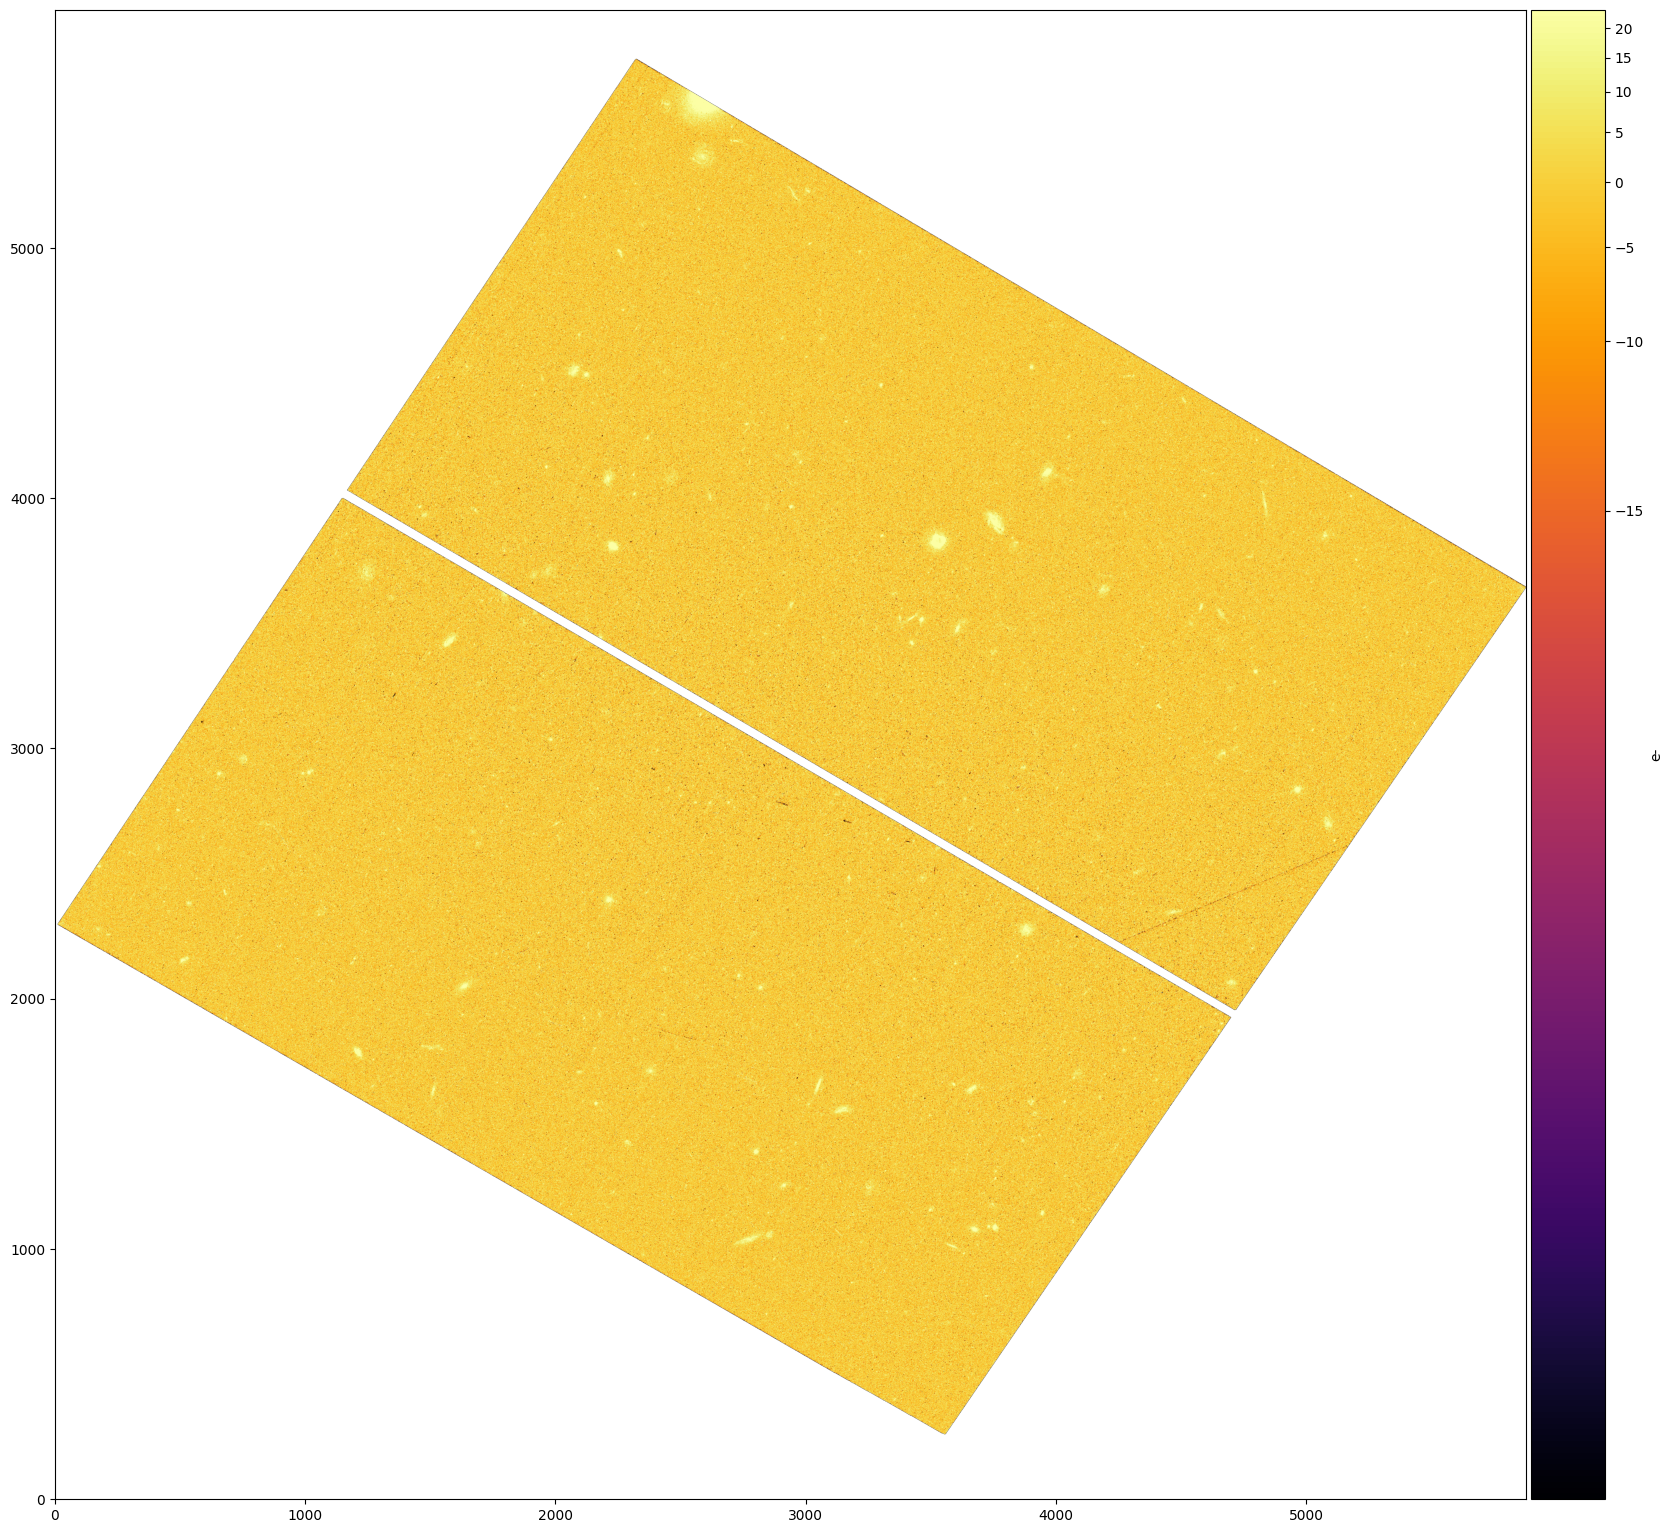

data and sigma2 will be replaced


In [4]:
data.from_raw_to_clean(box_size=64,inplace=True)

In [18]:
2**6

64

for the cut out

values use for fwhm = 3.5 and threshold = 1


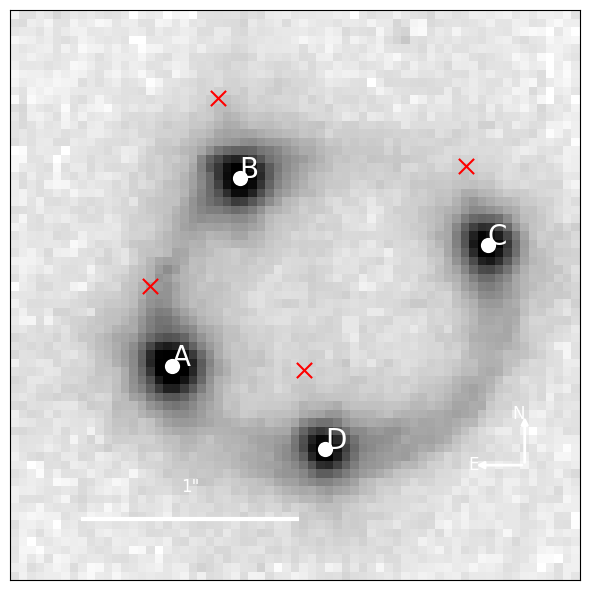

In [23]:
data.cut_out_lens(times_maxsep=1.9, plot=True, refine_centers=True, centroid_box_size=21, centroid_method="2dg",
                  num_pix=67,detec_fwhm=3.5,threshold = 1,skycorr = np.array([0,-1e-4]))

In [24]:
region_path = "../../few_stars_475.reg"

The search for stars will be with detec_fwhm = 5.000 and threshold = 0.075
Detected 4 stars outside the object region.


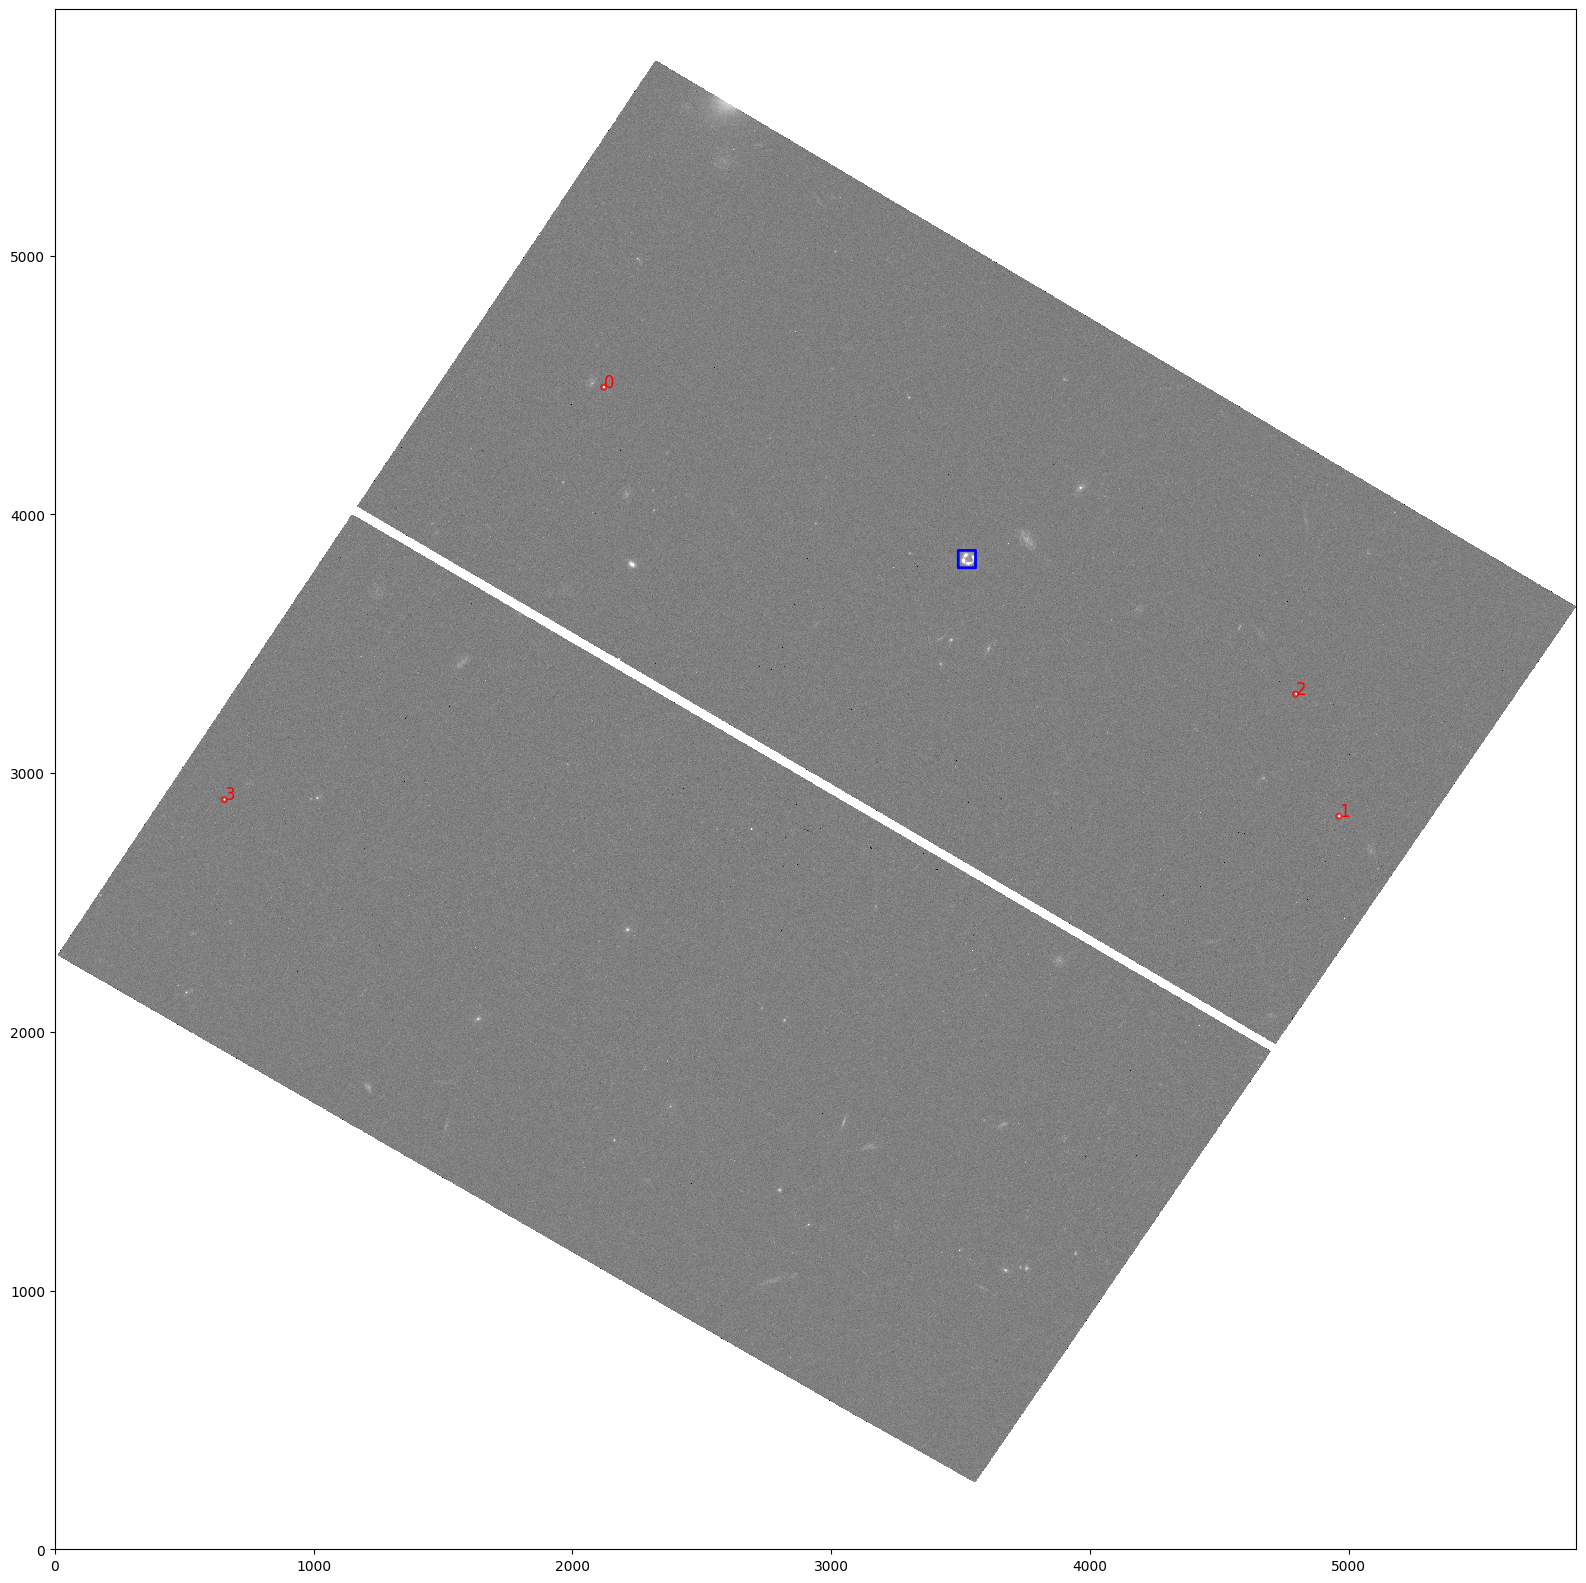


Calling make_cutouts with 4 sources.

Star ID 1: (x,y) = (2122, 4492)
The read in x, y are: 2122.209285080262 4492.265442557059
x_shift, y_shift = -0.20929 -0.26544
Before shift centroid = 22.0436 22.1053
After shift centroid =  21.9897 22.0404
The subimage peak flux (x,y) = (22), 22)
Scaling the stars peak flux to unity...


/Users/felavila/Work/MyPackages/SFstarred/SFstarred/plots.py:466: RuntimeWarning: invalid value encountered in log10
  mysubplot[3].imshow(np.log10(data), origin='lower', aspect='equal')


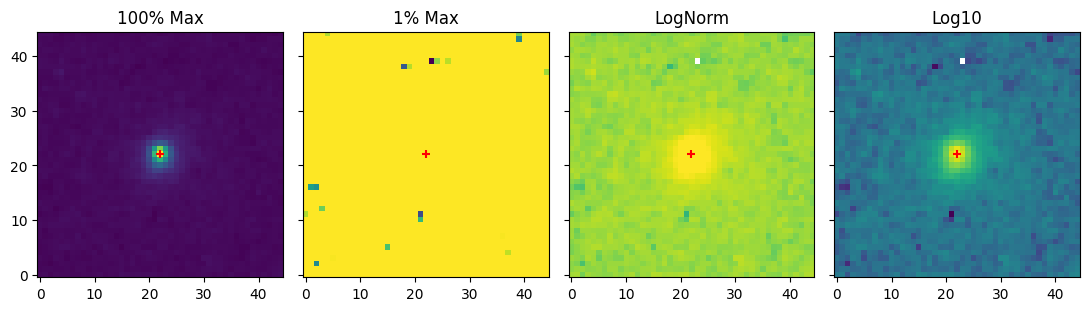

Star ID 2: (x,y) = (4963, 2835)
The read in x, y are: 4963.489798838599 2834.515157002845
x_shift, y_shift = -0.4898 0.48484
Before shift centroid = 22.1581 21.8239
After shift centroid =  21.9876 21.9913
The subimage peak flux (x,y) = (22), 22)
Scaling the stars peak flux to unity...


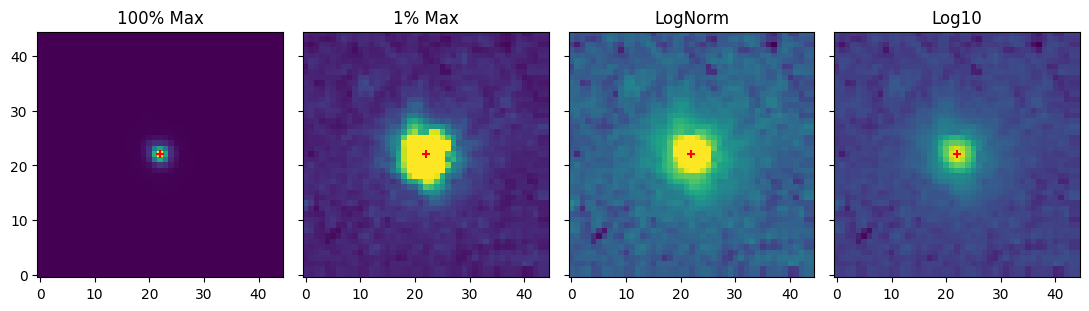

Star ID 3: (x,y) = (4796, 3306)
The read in x, y are: 4796.268782866759 3306.1046034221913
x_shift, y_shift = -0.26878 -0.1046
Before shift centroid = 22.071 22.0728
After shift centroid =  21.9971 22.0294
The subimage peak flux (x,y) = (22), 22)
Scaling the stars peak flux to unity...


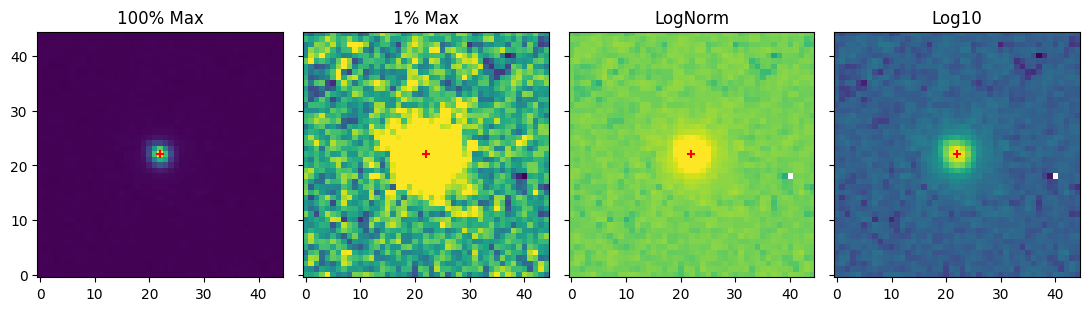

Star ID 4: (x,y) = (656, 2898)
The read in x, y are: 655.7521945605864 2897.8388189336724
x_shift, y_shift = 0.24781 0.16118
Before shift centroid = 21.8857 21.9261
After shift centroid =  21.9782 21.9859
The subimage peak flux (x,y) = (22), 22)
Scaling the stars peak flux to unity...


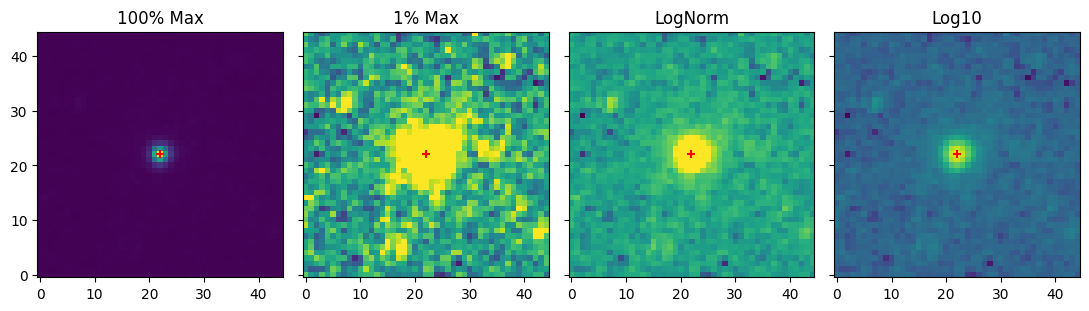

In [25]:

sources = data.from_region(region_path,detec_fwhm=None,threshold=None,verbose=True,make_plots=True,star_num_pix = 45)
##%%
#data_F160W.plot_stars()

### Finally to save 


Calling make_cutouts with 4 sources.

Star ID 1: (x,y) = (2122, 4492)
The read in x, y are: 2122.209285080262 4492.265442557059
x_shift, y_shift = -0.20929 -0.26544
Before shift centroid = 32.0436 32.1053
After shift centroid =  31.9897 32.0404
The subimage peak flux (x,y) = (32), 32)
Scaling the stars peak flux to unity...


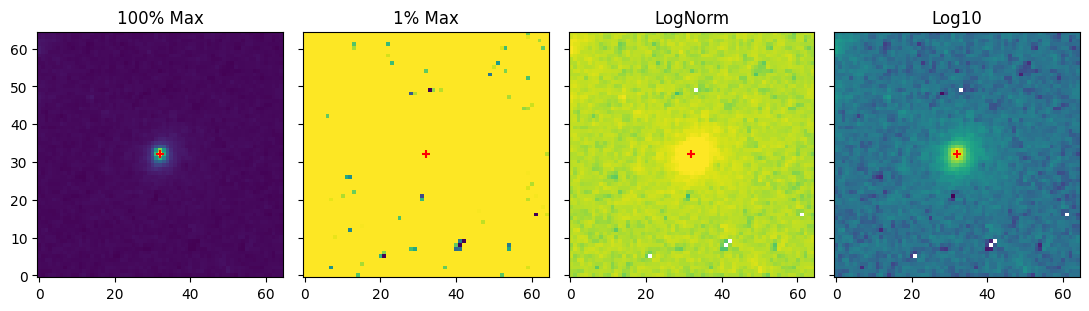

Star ID 2: (x,y) = (4963, 2835)
The read in x, y are: 4963.489798838599 2834.515157002845
x_shift, y_shift = -0.4898 0.48484
Before shift centroid = 32.1581 31.8239
After shift centroid =  31.9876 31.9913
The subimage peak flux (x,y) = (32), 32)
Scaling the stars peak flux to unity...


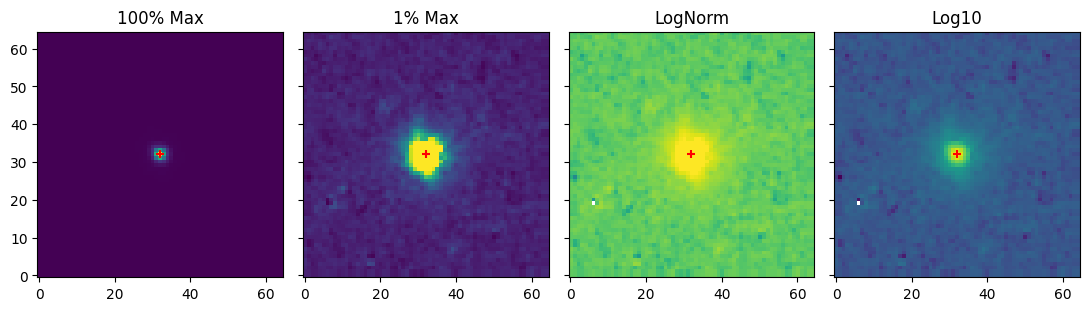

Star ID 3: (x,y) = (4796, 3306)
The read in x, y are: 4796.268782866759 3306.1046034221913
x_shift, y_shift = -0.26878 -0.1046
Before shift centroid = 32.071 32.0728
After shift centroid =  31.9971 32.0294
The subimage peak flux (x,y) = (32), 32)
Scaling the stars peak flux to unity...


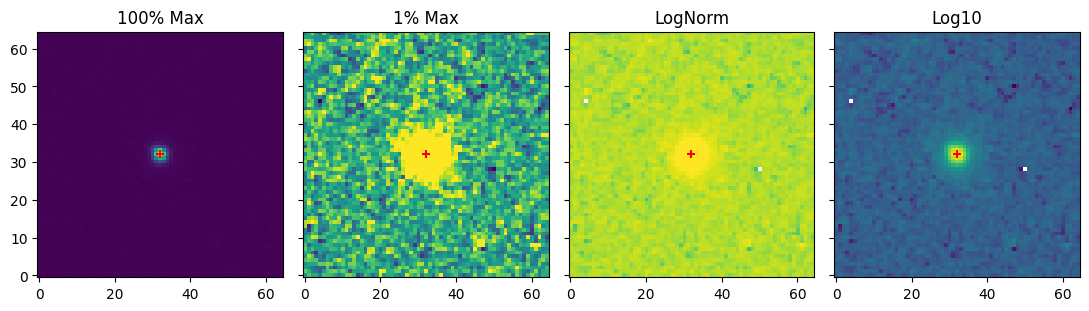

Star ID 4: (x,y) = (656, 2898)
The read in x, y are: 655.7521945605864 2897.8388189336724
x_shift, y_shift = 0.24781 0.16118
Before shift centroid = 31.8857 31.9261
After shift centroid =  31.9782 31.9859
The subimage peak flux (x,y) = (32), 32)
Scaling the stars peak flux to unity...


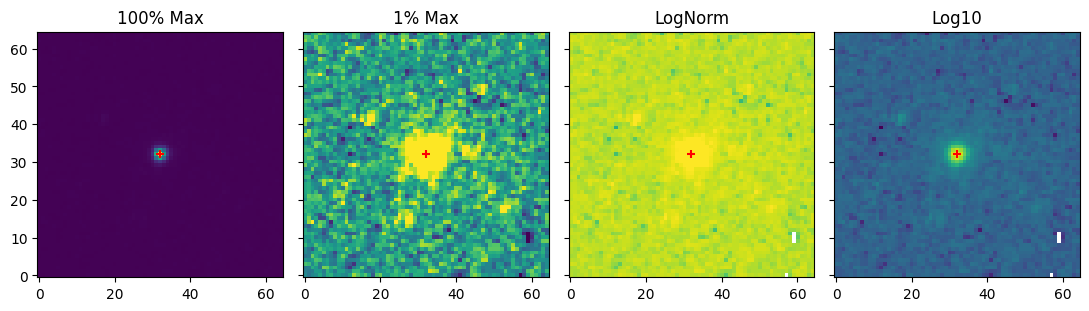

Saved STARRED dictionary to: data_for_starred/data_for_starred.pickle
ra, dec: [ 44.94471725 -16.61414538]


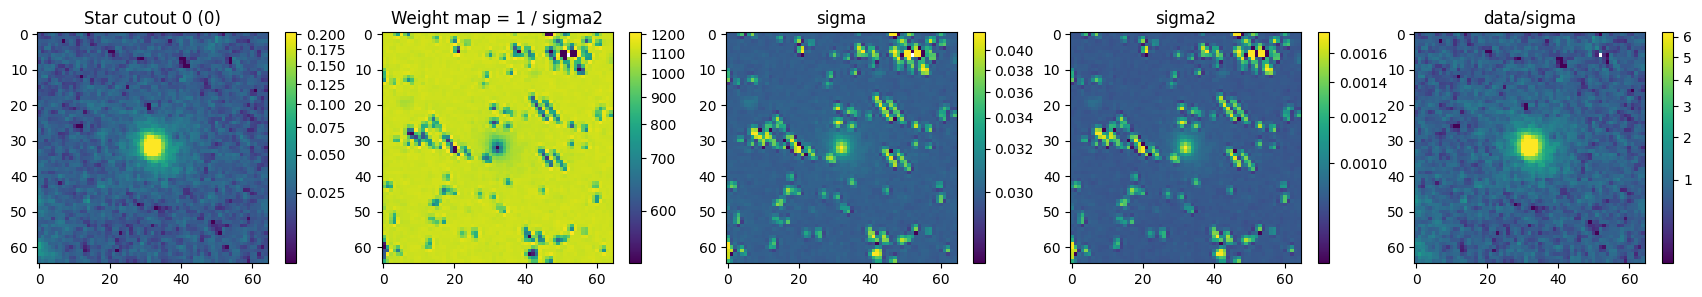

ra, dec: [ 44.91208883 -16.58287444]


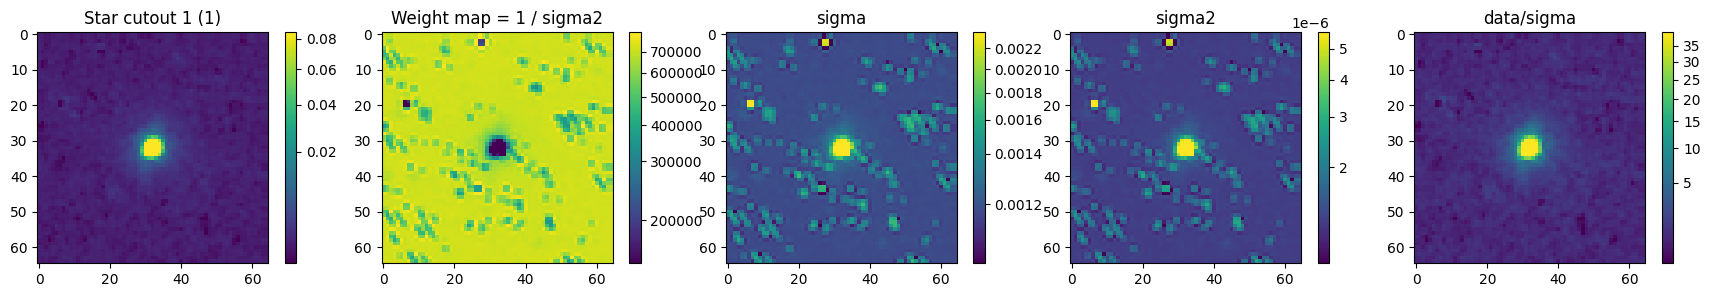

ra, dec: [ 44.91400885 -16.584715  ]


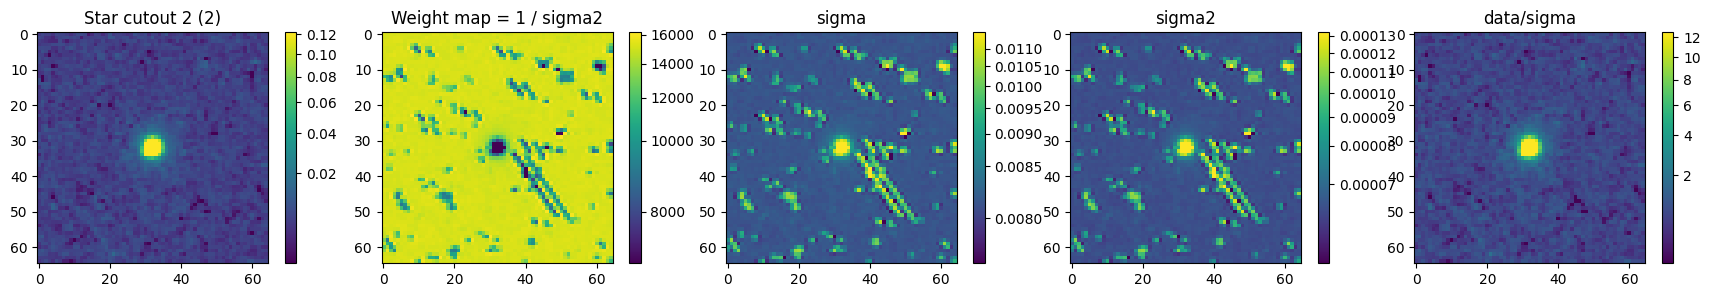

ra, dec: [ 44.96156176 -16.63028312]


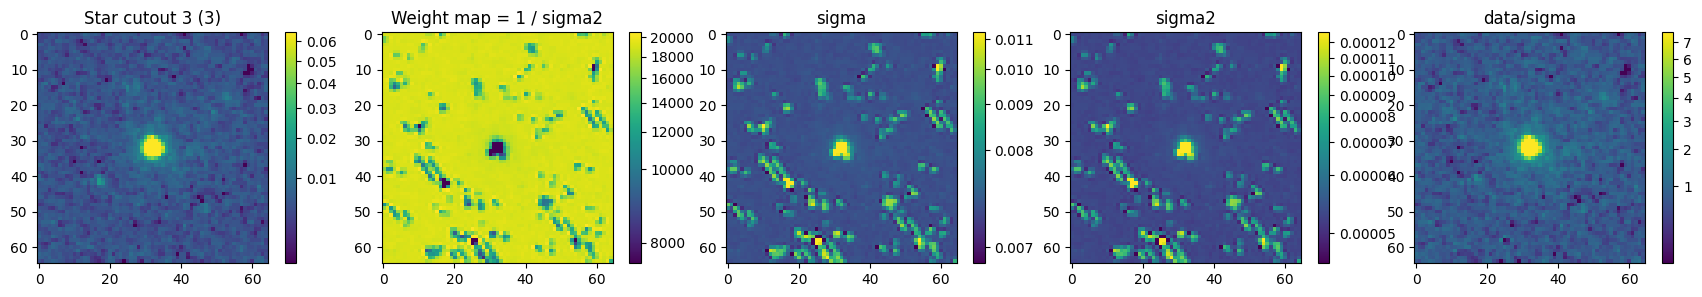

In [26]:
dict_result = data.save_for_starred(do_plots=True,non_selected_stars_index=[],verbose=True,save_path="data_for_starred/data_for_starred.pickle",
                                    plot_stars_percentile=(0.1,99),star_num_pix=64)

### read the data 

In [80]:
import pandas as pd 

In [22]:
dict_result_read = pd.read_pickle("data_for_starred/data_for_starred_F160_0214.pickle")

In [35]:
dict_result_read.keys()

dict_keys(['data', 'data_weight', 'data_noisemaps', 'stars', 'noisemaps_stars', 'coord_pix_images', 'images_names', 'coord_pix_images_dict', 'selected_star_indices', 'non_selected_stars_index', 'norm_factor'])